Device: cuda

Extracting Potato dataset...
Extraction directory already exists.

Dataset root:
/content/Potato_Dataset/Potato
Potato___Early_blight: 1000 images
Potato___Late_blight: 1000 images
Potato___healthy: 152 images

Total images: 2152

Training images: 1721
Validation images: 431

MORPH-DGNet v1
Total parameters: 7,080,411
Trainable parameters: 7,080,411


/tmp/ipykernel_553/2936960238.py:895: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  nn.TransformerEncoder(


Epoch [01/10] | Train Loss: 0.6498 | Train Acc: 80.48% | Val Loss: 0.4845 | Val Acc: 88.17% | LR: 0.0000976
  ✓ Best model saved (88.17%)
Epoch [02/10] | Train Loss: 0.4502 | Train Acc: 91.98% | Val Loss: 0.3800 | Val Acc: 94.90% | LR: 0.0000905
  ✓ Best model saved (94.90%)
Epoch [03/10] | Train Loss: 0.4220 | Train Acc: 93.84% | Val Loss: 0.4292 | Val Acc: 92.58% | LR: 0.0000794
Epoch [04/10] | Train Loss: 0.4067 | Train Acc: 94.36% | Val Loss: 0.3925 | Val Acc: 94.90% | LR: 0.0000655
Epoch [05/10] | Train Loss: 0.3726 | Train Acc: 95.99% | Val Loss: 0.3793 | Val Acc: 95.13% | LR: 0.0000500
  ✓ Best model saved (95.13%)
Epoch [06/10] | Train Loss: 0.3657 | Train Acc: 96.11% | Val Loss: 0.3378 | Val Acc: 98.14% | LR: 0.0000345
  ✓ Best model saved (98.14%)
Epoch [07/10] | Train Loss: 0.3584 | Train Acc: 96.75% | Val Loss: 0.4009 | Val Acc: 94.20% | LR: 0.0000206
Epoch [08/10] | Train Loss: 0.3444 | Train Acc: 97.50% | Val Loss: 0.3318 | Val Acc: 97.22% | LR: 0.0000095
Epoch [09/10] | 

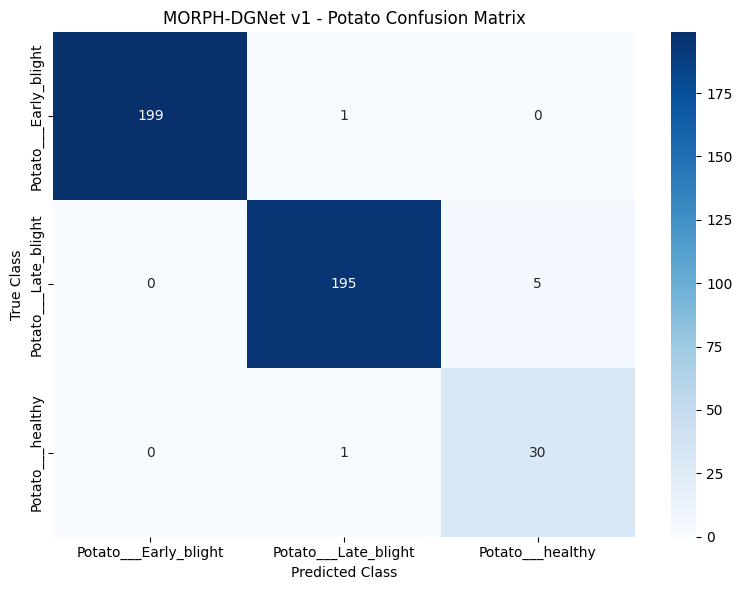

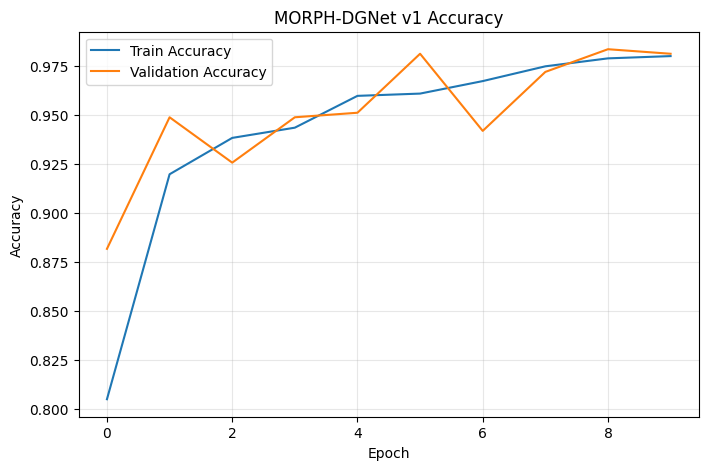

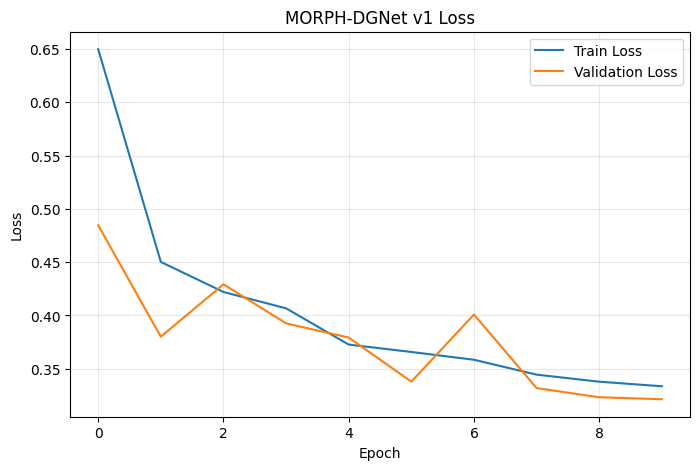


MORPH-DGNet v1 TRAINING COMPLETE
Best model: /content/MORPH_DGNet_v1_Potato_best.pth


In [ ]:
# ============================================================
# MORPH-DGNet v1
# Morphology-Guided CNN + ViT + SE
#
# POTATO LEAF DISEASE CLASSIFICATION
#
# Classes:
#   Potato___Early_blight
#   Potato___Late_blight
#   Potato___healthy
#
# Input: 224 x 224 RGB
# Framework: PyTorch
# ============================================================

# ============================================================
# 1. IMPORTS
# ============================================================

import os
import zipfile
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import (
    Dataset,
    DataLoader,
    random_split
)

from torchvision import transforms

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

# ============================================================
# 2. CONFIGURATION
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)

# ------------------------------------------------------------
# Dataset
# ------------------------------------------------------------

ZIP_PATH = "/content/Potato.zip"

EXTRACT_DIR = "/content/Potato_Dataset"

IMAGE_SIZE = 224

BATCH_SIZE = 32

NUM_CLASSES = 3

EPOCHS = 10

LEARNING_RATE = 1e-4

WEIGHT_DECAY = 1e-4

VAL_SPLIT = 0.20

NUM_WORKERS = 2

# ============================================================
# 3. EXTRACT DATASET
# ============================================================

if os.path.exists(ZIP_PATH):

    print("\nExtracting Potato dataset...")

    if not os.path.exists(EXTRACT_DIR):

        os.makedirs(
            EXTRACT_DIR,
            exist_ok=True
        )

        with zipfile.ZipFile(
            ZIP_PATH,
            "r"
        ) as zip_ref:

            zip_ref.extractall(
                EXTRACT_DIR
            )

        print("Extraction completed.")

    else:

        print(
            "Extraction directory already exists."
        )

else:

    raise FileNotFoundError(
        f"Dataset not found: {ZIP_PATH}"
    )


# ============================================================
# 4. FIND DATASET ROOT
# ============================================================

CLASS_NAMES = [
    "Potato___Early_blight",
    "Potato___Late_blight",
    "Potato___healthy"
]

IMAGE_EXTENSIONS = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
)


def find_dataset_root(root):

    candidates = []

    for current_root, dirs, files in os.walk(root):

        found_classes = 0

        for cls in CLASS_NAMES:

            if os.path.isdir(
                os.path.join(current_root, cls)
            ):
                found_classes += 1

        if found_classes == len(CLASS_NAMES):

            candidates.append(current_root)

    if len(candidates) == 0:

        return None

    return candidates[0]


DATASET_ROOT = find_dataset_root(
    EXTRACT_DIR
)

if DATASET_ROOT is None:

    print("\nCould not find the expected 3-class structure.")

    print("\nFolders found:")

    for root, dirs, files in os.walk(EXTRACT_DIR):

        level = root.replace(
            EXTRACT_DIR,
            ""
        ).count(os.sep)

        if level <= 2:

            print(
                "  " * level +
                os.path.basename(root)
            )

    raise RuntimeError(
        "\nExpected class folders were not found."
    )

print("\nDataset root:")
print(DATASET_ROOT)


# ============================================================
# 5. COLLECT IMAGE PATHS
# ============================================================

image_paths = []
labels = []

class_to_idx = {
    cls: idx
    for idx, cls in enumerate(CLASS_NAMES)
}

for cls in CLASS_NAMES:

    class_dir = os.path.join(
        DATASET_ROOT,
        cls
    )

    files = []

    for root, _, filenames in os.walk(
        class_dir
    ):

        for filename in filenames:

            if filename.lower().endswith(
                IMAGE_EXTENSIONS
            ):

                files.append(
                    os.path.join(
                        root,
                        filename
                    )
                )

    print(
        f"{cls}: {len(files)} images"
    )

    for path in files:

        image_paths.append(path)

        labels.append(
            class_to_idx[cls]
        )


print(
    "\nTotal images:",
    len(image_paths)
)


# ============================================================
# 6. DATASET
# ============================================================

class PotatoDataset(Dataset):

    def __init__(
        self,
        image_paths,
        labels,
        transform=None
    ):

        self.image_paths = image_paths

        self.labels = labels

        self.transform = transform

    def __len__(self):

        return len(self.image_paths)

    def __getitem__(self, idx):

        path = self.image_paths[idx]

        label = self.labels[idx]

        try:

            image = Image.open(
                path
            ).convert("RGB")

        except Exception as e:

            print(
                "Error reading:",
                path
            )

            raise e

        if self.transform:

            image = self.transform(
                image
            )

        return image, label


# ============================================================
# 7. TRANSFORMS
# ============================================================

train_transform = transforms.Compose([

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomVerticalFlip(
        p=0.2
    ),

    transforms.RandomRotation(
        15
    ),

    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.15,
        hue=0.03
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[
            0.485,
            0.456,
            0.406
        ],
        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])


val_transform = transforms.Compose([

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[
            0.485,
            0.456,
            0.406
        ],
        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])


# ============================================================
# 8. STRATIFIED SPLIT
# ============================================================

indices = np.arange(
    len(image_paths)
)

labels_np = np.array(
    labels
)

train_indices = []
val_indices = []

for class_id in range(
    NUM_CLASSES
):

    class_indices = indices[
        labels_np == class_id
    ]

    np.random.shuffle(
        class_indices
    )

    split = int(
        len(class_indices)
        * (1 - VAL_SPLIT)
    )

    train_indices.extend(
        class_indices[:split]
    )

    val_indices.extend(
        class_indices[split:]
    )


random.shuffle(
    train_indices
)

random.shuffle(
    val_indices
)


train_paths = [
    image_paths[i]
    for i in train_indices
]

train_labels = [
    labels[i]
    for i in train_indices
]

val_paths = [
    image_paths[i]
    for i in val_indices
]

val_labels = [
    labels[i]
    for i in val_indices
]


train_dataset = PotatoDataset(
    train_paths,
    train_labels,
    transform=train_transform
)

val_dataset = PotatoDataset(
    val_paths,
    val_labels,
    transform=val_transform
)


print(
    "\nTraining images:",
    len(train_dataset)
)

print(
    "Validation images:",
    len(val_dataset)
)


# ============================================================
# 9. DATALOADERS
# ============================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)


# ============================================================
# 10. SE BLOCK
# ============================================================

class SEBlock(nn.Module):

    def __init__(
        self,
        channels,
        reduction=16
    ):

        super().__init__()

        hidden = max(
            channels // reduction,
            4
        )

        self.pool = nn.AdaptiveAvgPool2d(
            1
        )

        self.fc = nn.Sequential(

            nn.Linear(
                channels,
                hidden
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.Linear(
                hidden,
                channels
            ),

            nn.Sigmoid()
        )

    def forward(self, x):

        b, c, _, _ = x.shape

        y = self.pool(
            x
        ).view(
            b,
            c
        )

        y = self.fc(
            y
        ).view(
            b,
            c,
            1,
            1
        )

        return x * y


# ============================================================
# 11. CNN BLOCK
# ============================================================

class CNNBlock(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels
    ):

        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            padding=1,
            bias=False
        )

        self.bn1 = nn.BatchNorm2d(
            out_channels
        )

        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            padding=1,
            bias=False
        )

        self.bn2 = nn.BatchNorm2d(
            out_channels
        )

        self.act = nn.GELU()

        self.se = SEBlock(
            out_channels
        )

        if in_channels != out_channels:

            self.skip = nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=1,
                bias=False
            )

        else:

            self.skip = nn.Identity()

    def forward(self, x):

        residual = self.skip(x)

        x = self.conv1(x)

        x = self.bn1(x)

        x = self.act(x)

        x = self.conv2(x)

        x = self.bn2(x)

        x = self.act(x)

        x = self.se(x)

        return x + residual


# ============================================================
# 12. CNN BRANCH
# ============================================================

class CNNBranch(nn.Module):

    def __init__(
        self,
        channels=(32, 64, 128, 256)
    ):

        super().__init__()

        self.stage1 = CNNBlock(
            3,
            channels[0]
        )

        self.stage2 = CNNBlock(
            channels[0],
            channels[1]
        )

        self.stage3 = CNNBlock(
            channels[1],
            channels[2]
        )

        self.stage4 = CNNBlock(
            channels[2],
            channels[3]
        )

        self.pool = nn.MaxPool2d(
            kernel_size=2
        )

    def forward(self, x):

        x = self.stage1(x)

        x = self.pool(x)

        x = self.stage2(x)

        x = self.pool(x)

        x = self.stage3(x)

        x = self.pool(x)

        x = self.stage4(x)

        return x


# ============================================================
# 13. MORPHOLOGY MODULE
# ============================================================

class MorphologyModule(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels
    ):

        super().__init__()

        self.projection = nn.Sequential(

            nn.Conv2d(
                in_channels * 4,
                out_channels,
                kernel_size=1,
                bias=False
            ),

            nn.BatchNorm2d(
                out_channels
            ),

            nn.GELU()
        )

        self.se = SEBlock(
            out_channels
        )

    def dilation(self, x):

        return F.max_pool2d(
            x,
            kernel_size=3,
            stride=1,
            padding=1
        )

    def erosion(self, x):

        return -F.max_pool2d(
            -x,
            kernel_size=3,
            stride=1,
            padding=1
        )

    def forward(self, x):

        dilation = self.dilation(x)

        erosion = self.erosion(x)

        opening = self.dilation(
            erosion
        )

        closing = self.erosion(
            dilation
        )

        morphology = torch.cat(
            [
                dilation,
                erosion,
                opening,
                closing
            ],
            dim=1
        )

        morphology = self.projection(
            morphology
        )

        morphology = self.se(
            morphology
        )

        return morphology


# ============================================================
# 14. PATCH EMBEDDING
# ============================================================

class PatchEmbedding(nn.Module):

    def __init__(
        self,
        image_size=224,
        patch_size=16,
        in_channels=3,
        embed_dim=256
    ):

        super().__init__()

        assert image_size % patch_size == 0

        self.num_patches = (
            image_size // patch_size
        ) ** 2

        self.projection = nn.Conv2d(
            in_channels,
            embed_dim,
            kernel_size=patch_size,
            stride=patch_size
        )

    def forward(self, x):

        x = self.projection(x)

        x = x.flatten(2)

        x = x.transpose(
            1,
            2
        )

        return x


# ============================================================
# 15. VISION TRANSFORMER
# ============================================================

class ViTBranch(nn.Module):

    def __init__(
        self,
        image_size=224,
        patch_size=16,
        embed_dim=256,
        depth=6,
        heads=8,
        mlp_ratio=4.0,
        dropout=0.1
    ):

        super().__init__()

        self.patch_embed = PatchEmbedding(
            image_size=image_size,
            patch_size=patch_size,
            in_channels=3,
            embed_dim=embed_dim
        )

        num_patches = (
            image_size // patch_size
        ) ** 2

        self.cls_token = nn.Parameter(
            torch.zeros(
                1,
                1,
                embed_dim
            )
        )

        self.pos_embed = nn.Parameter(
            torch.zeros(
                1,
                num_patches + 1,
                embed_dim
            )
        )

        self.dropout = nn.Dropout(
            dropout
        )

        encoder_layer = (
            nn.TransformerEncoderLayer(
                d_model=embed_dim,
                nhead=heads,
                dim_feedforward=int(
                    embed_dim * mlp_ratio
                ),
                dropout=dropout,
                activation="gelu",
                batch_first=True,
                norm_first=True
            )
        )

        self.transformer = (
            nn.TransformerEncoder(
                encoder_layer,
                num_layers=depth
            )
        )

        self.norm = nn.LayerNorm(
            embed_dim
        )

        nn.init.trunc_normal_(
            self.pos_embed,
            std=0.02
        )

        nn.init.trunc_normal_(
            self.cls_token,
            std=0.02
        )

    def forward(self, x):

        x = self.patch_embed(x)

        b = x.shape[0]

        cls = self.cls_token.expand(
            b,
            -1,
            -1
        )

        x = torch.cat(
            [cls, x],
            dim=1
        )

        x = x + self.pos_embed

        x = self.dropout(x)

        x = self.transformer(x)

        x = self.norm(x)

        return x[:, 0]


# ============================================================
# 16. CNN PROJECTION
# ============================================================

class CNNProjection(nn.Module):

    def __init__(
        self,
        in_channels,
        out_dim
    ):

        super().__init__()

        self.pool = (
            nn.AdaptiveAvgPool2d(1)
        )

        self.fc = nn.Linear(
            in_channels,
            out_dim
        )

    def forward(self, x):

        x = self.pool(x)

        x = torch.flatten(
            x,
            1
        )

        return self.fc(x)


# ============================================================
# 17. VECTOR SE
# ============================================================

class SEVector(nn.Module):

    def __init__(
        self,
        channels,
        reduction=16
    ):

        super().__init__()

        hidden = max(
            channels // reduction,
            4
        )

        self.fc = nn.Sequential(

            nn.Linear(
                channels,
                hidden
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.Linear(
                hidden,
                channels
            ),

            nn.Sigmoid()
        )

    def forward(self, x):

        return x * self.fc(x)


# ============================================================
# 18. MORPHOLOGY-GUIDED FUSION
# ============================================================

class MorphologyGuidedFusion(nn.Module):

    def __init__(
        self,
        cnn_dim=256,
        vit_dim=256,
        morph_dim=128,
        fusion_dim=256
    ):

        super().__init__()

        self.cnn_proj = nn.Linear(
            cnn_dim,
            fusion_dim
        )

        self.vit_proj = nn.Linear(
            vit_dim,
            fusion_dim
        )

        self.morph_proj = nn.Linear(
            morph_dim,
            fusion_dim
        )

        # ----------------------------------------------------
        # Morphology-guided dynamic gate
        # ----------------------------------------------------

        self.gate = nn.Sequential(

            nn.Linear(
                fusion_dim * 3,
                fusion_dim
            ),

            nn.GELU(),

            nn.Linear(
                fusion_dim,
                fusion_dim
            ),

            nn.Sigmoid()
        )

        self.fusion = nn.Sequential(

            nn.Linear(
                fusion_dim * 3,
                fusion_dim
            ),

            nn.LayerNorm(
                fusion_dim
            ),

            nn.GELU(),

            nn.Dropout(
                0.2
            )
        )

        self.se = SEVector(
            fusion_dim
        )

    def forward(
        self,
        cnn_features,
        vit_features,
        morph_features
    ):

        cnn = self.cnn_proj(
            cnn_features
        )

        vit = self.vit_proj(
            vit_features
        )

        morph = self.morph_proj(
            morph_features
        )

        combined = torch.cat(
            [
                cnn,
                vit,
                morph
            ],
            dim=1
        )

        gate = self.gate(
            combined
        )

        cnn_guided = (
            cnn * (1.0 + gate)
        )

        vit_guided = (
            vit * (1.0 + gate)
        )

        fused = torch.cat(
            [
                cnn_guided,
                vit_guided,
                morph
            ],
            dim=1
        )

        fused = self.fusion(
            fused
        )

        fused = self.se(
            fused
        )

        return fused


# ============================================================
# 19. MORPH-DGNet v1
# ============================================================

class MORPH_DGNet_v1(nn.Module):

    def __init__(
        self,
        num_classes=3,
        image_size=224,
        cnn_channels=(
            32,
            64,
            128,
            256
        ),
        vit_dim=256,
        vit_depth=6,
        vit_heads=8,
        patch_size=16,
        fusion_dim=256
    ):

        super().__init__()

        # ----------------------------------------------------
        # CNN
        # ----------------------------------------------------

        self.cnn = CNNBranch(
            channels=cnn_channels
        )

        # ----------------------------------------------------
        # ViT
        # ----------------------------------------------------

        self.vit = ViTBranch(
            image_size=image_size,
            patch_size=patch_size,
            embed_dim=vit_dim,
            depth=vit_depth,
            heads=vit_heads
        )

        # ----------------------------------------------------
        # Morphology
        # ----------------------------------------------------

        self.morphology = MorphologyModule(
            in_channels=cnn_channels[-1],
            out_channels=128
        )

        # ----------------------------------------------------
        # CNN projection
        # ----------------------------------------------------

        self.cnn_projection = CNNProjection(
            cnn_channels[-1],
            256
        )

        # ----------------------------------------------------
        # Morphology pooling
        # ----------------------------------------------------

        self.morph_pool = (
            nn.AdaptiveAvgPool2d(1)
        )

        # ----------------------------------------------------
        # Fusion
        # ----------------------------------------------------

        self.fusion = (
            MorphologyGuidedFusion(
                cnn_dim=256,
                vit_dim=vit_dim,
                morph_dim=128,
                fusion_dim=fusion_dim
            )
        )

        # ----------------------------------------------------
        # Classifier
        # ----------------------------------------------------

        self.classifier = nn.Sequential(

            nn.Linear(
                fusion_dim,
                fusion_dim // 2
            ),

            nn.LayerNorm(
                fusion_dim // 2
            ),

            nn.GELU(),

            nn.Dropout(
                0.3
            ),

            nn.Linear(
                fusion_dim // 2,
                num_classes
            )
        )

    def forward(self, x):

        # CNN
        cnn_features = self.cnn(x)

        cnn_vector = (
            self.cnn_projection(
                cnn_features
            )
        )

        # Morphology
        morph_features = (
            self.morphology(
                cnn_features
            )
        )

        morph_vector = (
            self.morph_pool(
                morph_features
            )
        )

        morph_vector = torch.flatten(
            morph_vector,
            1
        )

        # ViT
        vit_vector = self.vit(x)

        # Fusion
        fused = self.fusion(
            cnn_vector,
            vit_vector,
            morph_vector
        )

        # Classification
        logits = self.classifier(
            fused
        )

        return logits


# ============================================================
# 20. CREATE MODEL
# ============================================================

model = MORPH_DGNet_v1(
    num_classes=3,
    image_size=224,
    cnn_channels=(
        32,
        64,
        128,
        256
    ),
    vit_dim=256,
    vit_depth=6,
    vit_heads=8,
    patch_size=16,
    fusion_dim=256
).to(DEVICE)


# ============================================================
# 21. MODEL SUMMARY
# ============================================================

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("\n" + "=" * 60)
print("MORPH-DGNet v1")
print("=" * 60)

print(
    f"Total parameters: "
    f"{total_params:,}"
)

print(
    f"Trainable parameters: "
    f"{trainable_params:,}"
)


# ============================================================
# 22. LOSS
# ============================================================

criterion = nn.CrossEntropyLoss(
    label_smoothing=0.1
)


# ============================================================
# 23. OPTIMIZER
# ============================================================

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)


# ============================================================
# 24. LR SCHEDULER
# ============================================================

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS
)


# ============================================================
# 25. TRAINING FUNCTION
# ============================================================

def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer
):

    model.train()

    running_loss = 0.0

    correct = 0

    total = 0

    for images, labels in loader:

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        outputs = model(
            images
        )

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        running_loss += (
            loss.item()
            * images.size(0)
        )

        predictions = (
            outputs.argmax(
                dim=1
            )
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

    epoch_loss = (
        running_loss / total
    )

    epoch_acc = (
        correct / total
    )

    return epoch_loss, epoch_acc


# ============================================================
# 26. VALIDATION FUNCTION
# ============================================================

@torch.no_grad()
def validate(
    model,
    loader,
    criterion
):

    model.eval()

    running_loss = 0.0

    correct = 0

    total = 0

    all_preds = []

    all_labels = []

    for images, labels in loader:

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True
        )

        outputs = model(
            images
        )

        loss = criterion(
            outputs,
            labels
        )

        running_loss += (
            loss.item()
            * images.size(0)
        )

        predictions = (
            outputs.argmax(
                dim=1
            )
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

        all_preds.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

    epoch_loss = (
        running_loss / total
    )

    epoch_acc = (
        correct / total
    )

    return (
        epoch_loss,
        epoch_acc,
        all_labels,
        all_preds
    )


# ============================================================
# 27. TRAINING LOOP
# ============================================================

best_val_acc = 0.0

best_model_path = (
    "/content/MORPH_DGNet_v1_Potato_best.pth"
)

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}


for epoch in range(
    EPOCHS
):

    train_loss, train_acc = (
        train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer
        )
    )

    val_loss, val_acc, _, _ = (
        validate(
            model,
            val_loader,
            criterion
        )
    )

    scheduler.step()

    history["train_loss"].append(
        train_loss
    )

    history["train_acc"].append(
        train_acc
    )

    history["val_loss"].append(
        val_loss
    )

    history["val_acc"].append(
        val_acc
    )

    current_lr = (
        optimizer.param_groups[0]["lr"]
    )

    print(
        f"Epoch [{epoch + 1:02d}/{EPOCHS}] "
        f"| Train Loss: {train_loss:.4f} "
        f"| Train Acc: {train_acc * 100:.2f}% "
        f"| Val Loss: {val_loss:.4f} "
        f"| Val Acc: {val_acc * 100:.2f}% "
        f"| LR: {current_lr:.7f}"
    )

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(
            {
                "model_state_dict":
                    model.state_dict(),

                "optimizer_state_dict":
                    optimizer.state_dict(),

                "val_accuracy":
                    val_acc,

                "class_names":
                    CLASS_NAMES
            },
            best_model_path
        )

        print(
            f"  ✓ Best model saved "
            f"({val_acc * 100:.2f}%)"
        )


# ============================================================
# 28. LOAD BEST MODEL
# ============================================================

checkpoint = torch.load(
    best_model_path,
    map_location=DEVICE
)

model.load_state_dict(
    checkpoint[
        "model_state_dict"
    ]
)

print(
    "\nBest validation accuracy:",
    f"{checkpoint['val_accuracy'] * 100:.2f}%"
)


# ============================================================
# 29. FINAL EVALUATION
# ============================================================

val_loss, val_acc, y_true, y_pred = (
    validate(
        model,
        val_loader,
        criterion
    )
)

print("\n" + "=" * 60)
print("FINAL POTATO RESULTS")
print("=" * 60)

print(
    f"Validation Accuracy: "
    f"{val_acc * 100:.2f}%"
)

print("\nClassification Report:\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=CLASS_NAMES,
        digits=4
    )
)


# ============================================================
# 30. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=np.arange(NUM_CLASSES)
)

print("\nConfusion Matrix:")

print(cm)


plt.figure(
    figsize=(8, 6)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "True Class"
)

plt.title(
    "MORPH-DGNet v1 - Potato Confusion Matrix"
)

plt.tight_layout()

plt.show()


# ============================================================
# 31. TRAINING CURVES
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    history["train_acc"],
    label="Train Accuracy"
)

plt.plot(
    history["val_acc"],
    label="Validation Accuracy"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Accuracy"
)

plt.title(
    "MORPH-DGNet v1 Accuracy"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.show()


plt.figure(
    figsize=(8, 5)
)

plt.plot(
    history["train_loss"],
    label="Train Loss"
)

plt.plot(
    history["val_loss"],
    label="Validation Loss"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "MORPH-DGNet v1 Loss"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.show()


# ============================================================
# 32. SINGLE IMAGE PREDICTION
# ============================================================

def predict_potato(
    image_path,
    model
):

    model.eval()

    transform = val_transform

    image = Image.open(
        image_path
    ).convert("RGB")

    tensor = transform(
        image
    ).unsqueeze(0).to(
        DEVICE
    )

    with torch.no_grad():

        output = model(
            tensor
        )

        probabilities = torch.softmax(
            output,
            dim=1
        )

        prediction = (
            probabilities.argmax(
                dim=1
            ).item()
        )

    print("\n" + "=" * 50)
    print("POTATO DISEASE PREDICTION")
    print("=" * 50)

    print(
        "Predicted:",
        CLASS_NAMES[prediction]
    )

    print(
        "Confidence:",
        f"{probabilities[0, prediction].item() * 100:.2f}%"
    )

    print("\nClass probabilities:")

    for i, cls in enumerate(
        CLASS_NAMES
    ):

        print(
            f"{cls}: "
            f"{probabilities[0, i].item() * 100:.2f}%"
        )

    return (
        CLASS_NAMES[prediction],
        probabilities[0].cpu().numpy()
    )


# ============================================================
# END
# ============================================================

print("\n" + "=" * 60)
print("MORPH-DGNet v1 TRAINING COMPLETE")
print("=" * 60)
print(
    "Best model:",
    best_model_path
)